In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/daily_counts.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Preview
print(df.head())

   barangay_psgc              species       date  count
0    102802046.0  Naja philippinensis 2025-10-10      1
1    102802046.0  Naja philippinensis 2025-10-15      1
2    102804012.0   Ophiophagus hannah 2026-01-17      1
3    102805018.0  Naja philippinensis 2025-11-08      1
4    102809016.0  Naja philippinensis 2025-10-17      1


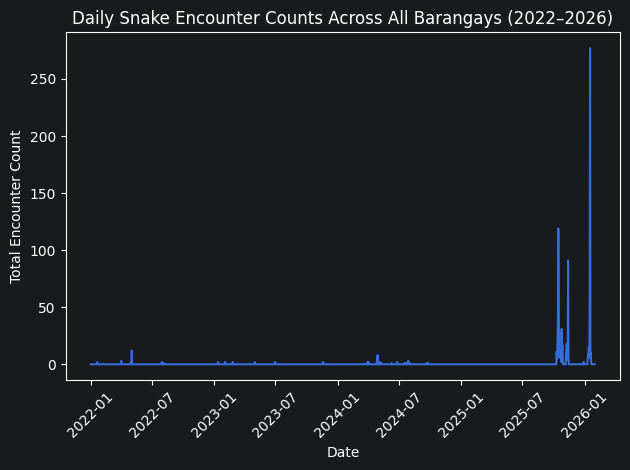

In [9]:
# Load data
df = pd.read_csv("../data/daily_counts.csv")
df['date'] = pd.to_datetime(df['date'])

# Aggregate total counts per day
daily_total = df.groupby('date')['count'].sum()

# Create FULL date range (Jan 2022 → Jan 2026)
full_range = pd.date_range(start="2022-01-01", end="2026-01-31")

# Reindex to include missing days → fill with 0
daily_total_full = daily_total.reindex(full_range, fill_value=0)

# Reset index for plotting
daily_total_full = daily_total_full.reset_index()
daily_total_full.columns = ['date', 'count']

# Plot
plt.figure()
plt.plot(daily_total_full['date'], daily_total_full['count'])

plt.xlabel("Date")
plt.ylabel("Total Encounter Count")
plt.title("Daily Snake Encounter Counts Across All Barangays (2022–2026)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [10]:
# Find the max spike
max_row = daily_total_full[daily_total_full['count'] == daily_total_full['count'].max()]
print(max_row)

           date  count
1477 2026-01-17    277


In [11]:
spike_date = max_row['date'].iloc[0]

# Show all rows for that date
print(df[df['date'] == spike_date].sort_values(by='count', ascending=False))

      barangay_psgc              species       date  count
551    5.017280e+08  Naja philippinensis 2026-01-17      4
282    3.054160e+08  Naja philippinensis 2026-01-17      3
249    3.049260e+08  Naja philippinensis 2026-01-17      3
79     1.055321e+08  Naja philippinensis 2026-01-17      3
177    3.008030e+08  Naja philippinensis 2026-01-17      3
...             ...                  ...        ...    ...
352    4.010190e+08  Naja philippinensis 2026-01-17      1
353    4.010190e+08  Naja philippinensis 2026-01-17      1
354    4.010190e+08  Naja philippinensis 2026-01-17      1
358    4.010210e+08  Naja philippinensis 2026-01-17      1
1020   1.903615e+09      Naja samarensis 2026-01-17      1

[237 rows x 4 columns]


In [12]:
subset = df[df['date'] == spike_date]

print("Total rows:", len(subset))
print("Sum count:", subset['count'].sum())
print("Unique barangays:", subset['barangay_psgc'].nunique())

Total rows: 237
Sum count: 277
Unique barangays: 227


In [13]:
print(df.sort_values(by='count', ascending=False).head(10))

     barangay_psgc              species       date  count
797   1.102319e+09      Naja samarensis 2022-05-02     12
801   1.102319e+09      Naja samarensis 2024-04-28      4
551   5.017280e+08  Naja philippinensis 2026-01-17      4
862   1.130700e+09      Naja samarensis 2025-11-13      4
134   2.031310e+08  Naja philippinensis 2025-10-15      4
282   3.054160e+08  Naja philippinensis 2026-01-17      3
615   7.012120e+08      Naja samarensis 2025-10-15      3
781   1.030500e+09      Naja samarensis 2025-10-15      3
853   1.130700e+09      Naja samarensis 2025-10-13      3
177   3.008030e+08  Naja philippinensis 2026-01-17      3


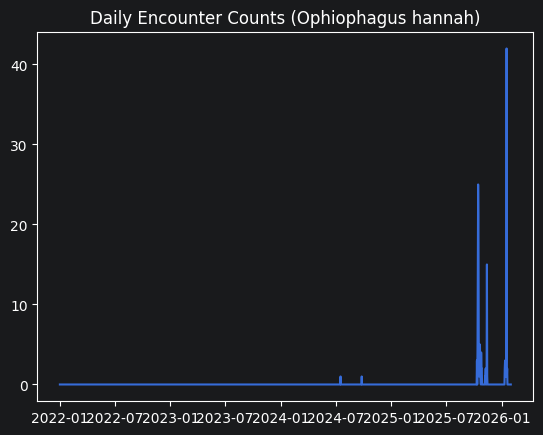

In [16]:
species = "Ophiophagus hannah"

df_species = df[df['species'] == species]

daily_total_species = df_species.groupby('date')['count'].sum()
daily_total_species = daily_total_species.reindex(full_range, fill_value=0)

plt.figure()
plt.plot(daily_total_species.index, daily_total_species.values)

plt.title(f"Daily Encounter Counts ({species})")
plt.show()

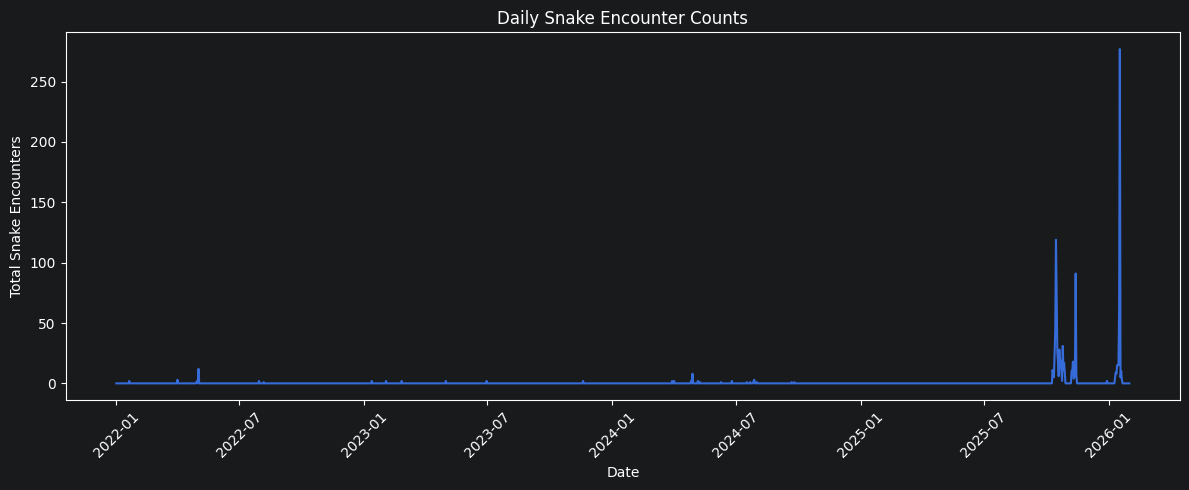

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# --- STEP 1: Load data ---
df = pd.read_csv("../data/daily_counts.csv")

# --- STEP 2: Convert date column to datetime ---
df['date'] = pd.to_datetime(df['date'])

# --- STEP 3: Filter date range (Jan 2022 to Jan 2026) ---
start_date = "2022-01-01"
end_date = "2026-01-31"

df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

# --- STEP 4: Aggregate total counts per day ---
daily_total = df.groupby('date')['count'].sum().reset_index()

# --- STEP 5: Create full date range (to show missing days as 0) ---
full_dates = pd.date_range(start=start_date, end=end_date)

daily_total = daily_total.set_index('date').reindex(full_dates, fill_value=0)
daily_total = daily_total.rename_axis('date').reset_index()

# --- STEP 6: Plot ---
plt.figure(figsize=(12, 5))
plt.plot(daily_total['date'], daily_total['count'])

plt.xlabel("Date")
plt.ylabel("Total Snake Encounters")
plt.title("Daily Snake Encounter Counts")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("raw_timeseries.png", dpi=300)
plt.show()

In [1]:
import pandas as pd
import numpy as np

# Load dataset used for sequence building
df = pd.read_csv("../data/model_dataset.csv")

print("Count column summary from data/model_dataset.csv")
print(df["count"].describe())

print("\nMin count:", df["count"].min())
print("Max count:", df["count"].max())

# Check if values are all between 0 and 1
all_between_0_1 = ((df["count"] >= 0) & (df["count"] <= 1)).all()
print("\nAre all count values between 0 and 1?", all_between_0_1)

# Optional: inspect unique small values
print("\nSample unique count values:")
print(sorted(df["count"].dropna().unique())[:20])

Count column summary from data/model_dataset.csv
count    2.994444e+06
mean     7.210020e-04
std      2.970042e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.200000e+01
Name: count, dtype: float64

Min count: 0
Max count: 12

Are all count values between 0 and 1? False

Sample unique count values:
[0, 1, 2, 3, 4, 12]
